# Section 2.4 - Tariffs are Lower on AI-Related Products
Generates: figures/ai-tariffs.pdf/png.
**Run after 06** - appends to tables/ai-trade-results.tex.


In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
import os

In [2]:
# Define paths for output files
texfile = "../paper/tables/ai-trade-results.tex"
figfile = "../paper/figures/"

In [3]:
matlist = pd.read_csv('../data-input/hs10_classification_final_v3.csv')

# matlist = pd.read_csv('hs10_datacenter_relevance.csv')

# Convert to category
matlist['relevance'] = matlist['relevance'].astype('category')

# Or specify order if needed (e.g., for sorting/comparisons)
matlist['relevance'] = pd.Categorical(
    matlist['relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist['primary_category'] = matlist['primary_category'].astype('category')

matlist.rename(columns={'hs10_code': 'HS10'}, inplace=True)

In [4]:
matlist.head()

,relevance,confidence,primary_category,specific_use,reasoning,HS10,description,naics_code,naics_description
0,Low,100,Not_DC_Related,No application in data center context,Live purebred breeding horses are livestock us...,101210010,"HORSES, LIVE, PUREBRED BREEDING MALE",112920,HORSES AND OTHER EQUINE
1,Low,100,Not_DC_Related,Not applicable to data center construction or ...,Live horses are livestock animals with no conn...,101210020,"HORSES, LIVE, PUREBRED BREEDING FEMALE",112920,HORSES AND OTHER EQUINE
2,Low,100,Not_DC_Related,No application in data center construction or ...,Live horses are livestock animals with no rele...,101290090,"HORSES, LIVE, NESOI",112920,HORSES AND OTHER EQUINE
3,Low,100,Not_DC_Related,Not applicable - livestock animals have no rol...,Live donkeys/asses are livestock animals used ...,101300000,"ASSES, LIVE",112920,HORSES AND OTHER EQUINE
4,Low,100,Not_DC_Related,Not applicable to data center operations,Live cattle are agricultural livestock with no...,102210010,"CATTLE, LIVE, PUREBRED BREEDING MALE, DAIRY",11211X,Description not found for NAICS 11211X


In [5]:
df = pd.read_parquet('../data-input/TOTALdata-current.parquet')

df.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

df["HS2"] = df["HS10"].str[0:2]
df["HS4"] = df["HS10"].str[0:4]

df["HS10"] = df["HS10"].astype('int64')

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["imports"] = df["CON_VAL_MO"].astype(float)

df["duty"] = df["CAL_DUT_MO"].astype(float)

df.rename({"I_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
df = df[~df["HS2"].isin(excluded_hs2)]

In [6]:
df.tail()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty
2726615,TOTAL FOR ALL COUNTRIES,1031361,308288,1605514000,"OYSTERS, SMOKED",2026-01-01,HS10,16,1605,1031361.0,308288.0
2726616,TOTAL FOR ALL COUNTRIES,582408,92228,1605515000,"OYSTERS EXCEPT SMOKED, PREPARED OR PRESERVED",2026-01-01,HS10,16,1605,582408.0,92228.0
2726617,TOTAL FOR ALL COUNTRIES,310800,36176,1605520500,SCALLOP PRODUCTS WITH FISH MEAT; PREP MEALS,2026-01-01,HS10,16,1605,310800.0,36176.0
2726618,TOTAL FOR ALL COUNTRIES,412467,91158,1605526000,"SCALLOPS, PREPARED OR PRESERVED",2026-01-01,HS10,16,1605,412467.0,91158.0
2726619,TOTAL FOR ALL COUNTRIES,368316,37195,1605530500,MUSSEL PRODUCTS WITH FISH MEAT; PREP MEALS,2026-01-01,HS10,16,1605,368316.0,37195.0


In [7]:
# Merge Relevance category from matlist onto df
df = df.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

In [8]:
df.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty,relevance,primary_category,reasoning
0,TOTAL FOR ALL COUNTRIES,773010,0,602400000,"ROSES, GRAFTED OR NOT",2013-01-01,HS10,06,0602,773010.0,0.0,Low,Not_DC_Related,Roses are ornamental plants used for landscapi...
1,TOTAL FOR ALL COUNTRIES,6177543,0,602902000,"ORCHID PLANTS, LIVE",2013-01-01,HS10,06,0602,6177543.0,0.0,Low,Not_DC_Related,Live orchid plants are ornamental/decorative p...
2,TOTAL FOR ALL COUNTRIES,135786,0,602903010,CHRYSANTHEMUMS WITH SOIL ATTACHED TO ROOTS,2013-01-01,HS10,06,0602,135786.0,0.0,Low,Not_DC_Related,These are live flowering plants (chrysanthemum...
3,TOTAL FOR ALL COUNTRIES,169439,0,602903090,"HERBACEOUS PERENNIALS,WTH SOIL ATTACHED,LIVE,N...",2013-01-01,HS10,06,0602,169439.0,0.0,Low,Not_DC_Related,This product is live herbaceous perennial plan...
4,TOTAL FOR ALL COUNTRIES,2177498,25345,602904000,HERBACEOUS PERENNIALS WTHOUT SOIL ATTACHED NESOI,2013-01-01,HS10,06,0602,2177498.0,25345.0,Low,Not_DC_Related,Live herbaceous perennial plants from nurserie...


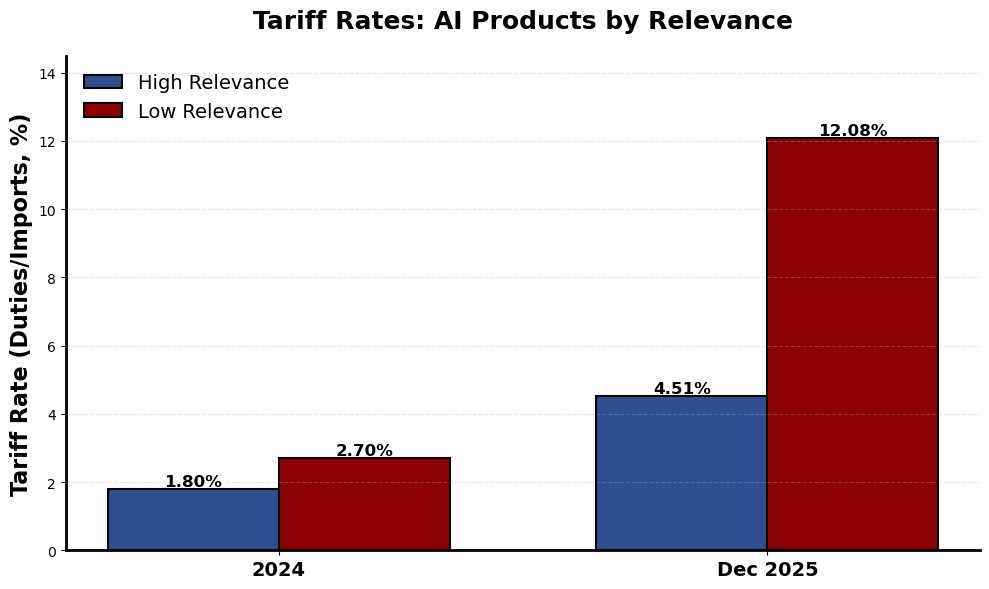


Tariff Rates (Duties/Imports):
  2024:
    High Relevance: 1.80%
    Low Relevance:  2.70%
  Dec 2025:
    High Relevance: 4.51%
    Low Relevance:  12.08%


In [9]:
# Calculate tariff rates (duty/imports) for High vs Low relevance products
# 2024 = full year, 2025 = December only

df_reset = df.reset_index()

labels = ['2024', 'Dec 2025']
tariff_data = {'High': [], 'Low': []}

# 2024: full year
year_data_2024 = df_reset[df_reset['time'].dt.year == 2024]
for rel in ['High', 'Low']:
    rel_data = year_data_2024[year_data_2024['relevance'] == rel]
    tariff_rate = (rel_data['duty'].sum() / rel_data['imports'].sum()) * 100
    tariff_data[rel].append(tariff_rate)

# 2025: December only
dec_2025 = df_reset[(df_reset['time'].dt.year == 2025) & (df_reset['time'].dt.month == 12)]
for rel in ['High', 'Low']:
    rel_data = dec_2025[dec_2025['relevance'] == rel]
    tariff_rate = (rel_data['duty'].sum() / rel_data['imports'].sum()) * 100
    tariff_data[rel].append(tariff_rate)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, tariff_data['High'], width, 
               label='High Relevance', color='#2E5090', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, tariff_data['Low'], width,
               label='Low Relevance', color='#8B0000', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting
ax.set_ylabel('Tariff Rate (Duties/Imports, %)', fontsize=16, fontweight='bold')
ax.set_title('Tariff Rates: AI Products by Relevance', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(max(tariff_data['High']), max(tariff_data['Low'])) * 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Make x-tick labels bold and larger
ax.tick_params(axis='x', labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.legend(fontsize=14, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

print(f"\nTariff Rates (Duties/Imports):")
for i, lbl in enumerate(labels):
    print(f"  {lbl}:")
    print(f"    High Relevance: {tariff_data['High'][i]:.2f}%")
    print(f"    Low Relevance:  {tariff_data['Low'][i]:.2f}%")

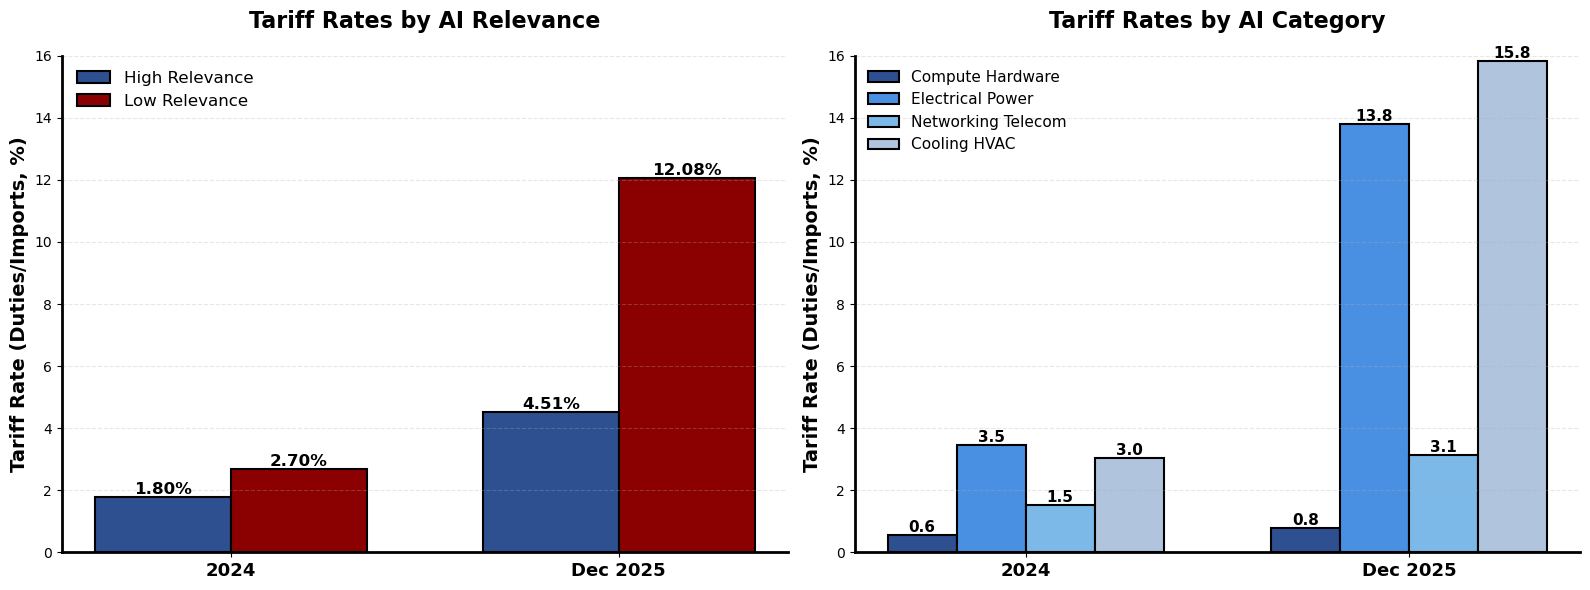


Tariff Rates Summary:

By Relevance:
  2024:
    High Relevance: 1.80%
    Low Relevance:  2.70%
  Dec 2025:
    High Relevance: 4.51%
    Low Relevance:  12.08%

By Category (High Relevance only):
  Compute Hardware:
    2024: 0.56%
    Dec 2025: 0.78%
  Electrical Power:
    2024: 3.46%
    Dec 2025: 13.80%
  Networking Telecom:
    2024: 1.54%
    Dec 2025: 3.14%
  Cooling HVAC:
    2024: 3.04%
    Dec 2025: 15.82%


In [10]:
# Two-panel figure: Tariff rates by category (left) and by relevance (right)
# 2024 = full year, 2025 = December only

labels = ['2024', 'Dec 2025']
df_reset = df.reset_index()

# Calculate tariff rates for relevance comparison (High vs Low)
tariff_data_relevance = {'High': [], 'Low': []}

# 2024: full year
year_data_2024 = df_reset[df_reset['time'].dt.year == 2024]
for rel in ['High', 'Low']:
    rel_data = year_data_2024[year_data_2024['relevance'] == rel]
    tariff_rate = (rel_data['duty'].sum() / rel_data['imports'].sum()) * 100
    tariff_data_relevance[rel].append(tariff_rate)

# 2025: December only
dec_2025 = df_reset[(df_reset['time'].dt.year == 2025) & (df_reset['time'].dt.month == 12)]
for rel in ['High', 'Low']:
    rel_data = dec_2025[dec_2025['relevance'] == rel]
    tariff_rate = (rel_data['duty'].sum() / rel_data['imports'].sum()) * 100
    tariff_data_relevance[rel].append(tariff_rate)

# Calculate tariff rates for category breakdown (only top 4 categories)
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()
top_4_cats = ['Compute_Hardware', 'Electrical_Power', 'Networking_Telecom', 'Cooling_HVAC']

category_tariffs_subset = {}
for cat in top_4_cats:
    category_tariffs_subset[cat] = []
    
    # 2024: full year
    cat_2024 = df_high_only[(df_high_only['time'].dt.year == 2024) & 
                             (df_high_only['primary_category'] == cat)]
    tariff_rate = (cat_2024['duty'].sum() / cat_2024['imports'].sum()) * 100
    category_tariffs_subset[cat].append(tariff_rate)
    
    # 2025: December only
    cat_dec_2025 = df_high_only[(df_high_only['time'].dt.year == 2025) & 
                                 (df_high_only['time'].dt.month == 12) &
                                 (df_high_only['primary_category'] == cat)]
    tariff_rate = (cat_dec_2025['duty'].sum() / cat_dec_2025['imports'].sum()) * 100
    category_tariffs_subset[cat].append(tariff_rate)

# Create two-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT PANEL: Tariff rates by relevance (High vs Low)
x = np.arange(len(labels))
width = 0.35

bars1 = ax1.bar(x - width/2, tariff_data_relevance['High'], width, 
               label='High Relevance', color='#2E5090', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, tariff_data_relevance['Low'], width,
               label='Low Relevance', color='#8B0000', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting left panel
ax1.set_ylabel('Tariff Rate (Duties/Imports, %)', fontsize=14, fontweight='bold')
ax1.set_title('Tariff Rates by AI Relevance', fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

ax1.set_ylim(0, 16)

ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', labelsize=13)
for label in ax1.get_xticklabels():
    label.set_fontweight('bold')
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.spines["left"].set_linewidth(2)
ax1.spines["bottom"].set_linewidth(2)
ax1.legend(fontsize=12, frameon=False, loc='upper left')

# RIGHT PANEL: Tariff rates by category (4 categories only)
x = np.arange(len(labels))
width = 0.18
n_cats = len(category_tariffs_subset)
offset = np.arange(n_cats) - (n_cats - 1) / 2

colors_cat = ['#2E5090', '#4A90E2', '#7CB9E8', '#B0C4DE']

for i, (cat, tariffs) in enumerate(category_tariffs_subset.items()):
    label = cat.replace('_', ' ')
    bars = ax2.bar(x + offset[i] * width, tariffs, width, 
                   label=label, color=colors_cat[i], 
                   edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Formatting right panel
ax2.set_ylabel('Tariff Rate (Duties/Imports, %)', fontsize=14, fontweight='bold')
ax2.set_title('Tariff Rates by AI Category', fontsize=16, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 16)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', labelsize=13)
for label in ax2.get_xticklabels():
    label.set_fontweight('bold')
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_linewidth(2)
ax2.spines["bottom"].set_linewidth(2)
ax2.legend(fontsize=11, frameon=False, loc='upper left', ncol=1)

plt.savefig(figfile+"ai-tariffs.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-tariffs.pdf", bbox_inches = "tight")

plt.tight_layout()
plt.show()

print(f"\nTariff Rates Summary:")
print(f"\nBy Relevance:")
for i, lbl in enumerate(labels):
    print(f"  {lbl}:")
    print(f"    High Relevance: {tariff_data_relevance['High'][i]:.2f}%")
    print(f"    Low Relevance:  {tariff_data_relevance['Low'][i]:.2f}%")

print(f"\nBy Category (High Relevance only):")
for cat, tariffs in category_tariffs_subset.items():
    print(f"  {cat.replace('_', ' ')}:")
    for i, lbl in enumerate(labels):
        print(f"    {lbl}: {tariffs[i]:.2f}%")

In [11]:
# Write tariff rate values to LaTeX file
# Note: 2024 = full year, 2025 = December only
with open(texfile, 'a') as f:
    # Tariff rates by relevance
    f.write(f'\\def\\tariffHighTwentyFour{{{tariff_data_relevance["High"][0]:.1f}}} % High AI relevance tariff rate in 2024 (%)\n')
    f.write(f'\\def\\tariffHighTwentyFive{{{tariff_data_relevance["High"][1]:.1f}}} % High AI relevance tariff rate in Dec 2025 (%)\n')
    f.write(f'\\def\\tariffLowTwentyFour{{{tariff_data_relevance["Low"][0]:.1f}}} % Low AI relevance tariff rate in 2024 (%)\n')
    f.write(f'\\def\\tariffLowTwentyFive{{{tariff_data_relevance["Low"][1]:.1f}}} % Low AI relevance tariff rate in Dec 2025 (%)\n')
    
    # Tariff rates by category
    for cat in top_4_cats:
        cat_clean = cat.replace('_', '')
        cat_name = cat.replace('_', ' ')
        tariffs = category_tariffs_subset[cat]
        f.write(f'\\newcommand{{\\tariff{cat_clean}TwentyFour}}{{{tariffs[0]:.1f}}} % {cat_name} tariff rate in 2024 (%)\n')
        f.write(f'\\newcommand{{\\tariff{cat_clean}TwentyFive}}{{{tariffs[1]:.1f}}} % {cat_name} tariff rate in Dec 2025 (%)\n')

print(f"\nAppended tariff rate values to {texfile}")
print(f"\nBy Relevance (2024 = full year, 2025 = Dec only):")
print(f"  High: {tariff_data_relevance['High'][0]:.1f}% (2024), {tariff_data_relevance['High'][1]:.1f}% (Dec 2025)")
print(f"  Low: {tariff_data_relevance['Low'][0]:.1f}% (2024), {tariff_data_relevance['Low'][1]:.1f}% (Dec 2025)")
print(f"\nBy Category:")
for cat in top_4_cats:
    tariffs = category_tariffs_subset[cat]
    print(f"  {cat.replace('_', ' ')}: {tariffs[0]:.1f}% (2024), {tariffs[1]:.1f}% (Dec 2025)")


Appended tariff rate values to ../paper/tables/ai-trade-results.tex

By Relevance (2024 = full year, 2025 = Dec only):
  High: 1.8% (2024), 4.5% (Dec 2025)
  Low: 2.7% (2024), 12.1% (Dec 2025)

By Category:
  Compute Hardware: 0.6% (2024), 0.8% (Dec 2025)
  Electrical Power: 3.5% (2024), 13.8% (Dec 2025)
  Networking Telecom: 1.5% (2024), 3.1% (Dec 2025)
  Cooling HVAC: 3.0% (2024), 15.8% (Dec 2025)


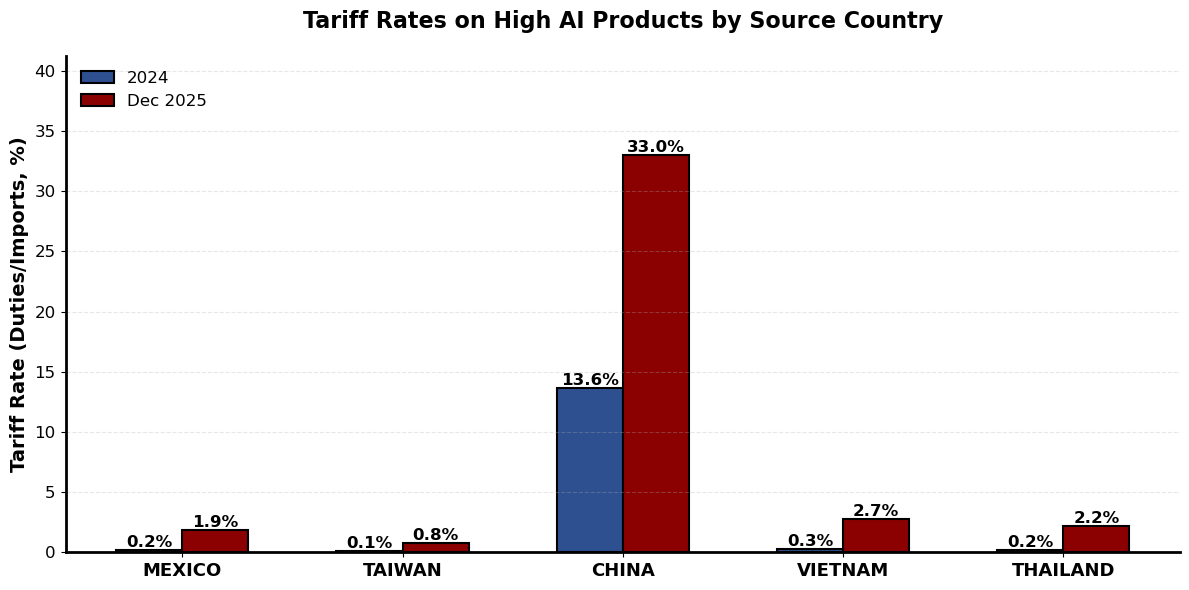


Country-specific tariff rates on High AI products:
  MEXICO: 2024=0.15% | Dec 2025=1.88%
  TAIWAN: 2024=0.09% | Dec 2025=0.80%
  CHINA: 2024=13.62% | Dec 2025=33.01%
  VIETNAM: 2024=0.30% | Dec 2025=2.75%
  THAILAND: 2024=0.15% | Dec 2025=2.21%


In [12]:
# Country-specific tariff rates on AI products: top 5 sources
# Load country-level import data
dfcountry = pd.read_parquet("../data-input/ALL-data-current.parquet")

dfcountry.rename(columns={"I_COMMODITY": "HS10"}, inplace=True)
dfcountry["HS2"] = dfcountry["HS10"].str[0:2]
dfcountry["HS10"] = dfcountry["HS10"].astype("int64")
dfcountry.time = pd.to_datetime(dfcountry.time, format="%Y-%m")
dfcountry["imports"] = dfcountry["CON_VAL_MO"].astype(float)
dfcountry["duty"] = dfcountry["CAL_DUT_MO"].astype(float)

# Remove volatile/special HS2 categories and aggregate rows
excluded_hs2 = ["27", "71", "98", "99"]
dfcountry = dfcountry[~dfcountry["HS2"].isin(excluded_hs2)]
excluded_cntry = ["TOTAL FOR ALL COUNTRIES", "USMCA (NAFTA)", "EUROPEAN UNION"]
dfcountry = dfcountry[~dfcountry["CTY_NAME"].isin(excluded_cntry)]

# Merge AI classification
dfcountry = dfcountry.merge(matlist[["HS10", "relevance"]], on="HS10", how="left")

# Filter to High AI relevance
country_high = dfcountry[dfcountry["relevance"] == "High"].copy()

# Identify top 5 countries by total High AI imports (2024-2025)
top5 = (
    country_high[country_high["time"].dt.year.isin([2024, 2025])]
    .groupby("CTY_NAME", observed=True)["imports"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

# Compute tariff rates by country: 2024 (full year) and Dec 2025
labels = ["2024", "Dec 2025"]
country_tariffs = {}

for cty in top5:
    cty_data = country_high[country_high["CTY_NAME"] == cty]
    tariffs = []

    # 2024: full year
    d24 = cty_data[cty_data["time"].dt.year == 2024]
    tariffs.append((d24["duty"].sum() / d24["imports"].sum()) * 100 if d24["imports"].sum() > 0 else 0.0)

    # Dec 2025
    d25 = cty_data[(cty_data["time"].dt.year == 2025) & (cty_data["time"].dt.month == 12)]
    tariffs.append((d25["duty"].sum() / d25["imports"].sum()) * 100 if d25["imports"].sum() > 0 else 0.0)

    country_tariffs[cty] = tariffs

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(top5))
width = 0.30

bars_24 = ax.bar(
    x - width/2,
    [country_tariffs[c][0] for c in top5],
    width,
    label="2024",
    color="#2E5090",
    edgecolor="black",
    linewidth=1.5
)

bars_25 = ax.bar(
    x + width/2,
    [country_tariffs[c][1] for c in top5],
    width,
    label="Dec 2025",
    color="#8B0000",
    edgecolor="black",
    linewidth=1.5
)

# Value labels on bars
for bars in [bars_24, bars_25]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

# Formatting
ax.set_ylabel("Tariff Rate (Duties/Imports, %)", fontsize=14, fontweight="bold")
ax.set_title("Tariff Rates on High AI Products by Source Country", fontsize=16, fontweight="bold", pad=20)
ax.set_xticks(x)
ax.set_xticklabels(top5)
max_val = max(max(t) for t in country_tariffs.values())
ax.set_ylim(0, max_val * 1.25)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)
ax.legend(fontsize=12, frameon=False, loc="upper left")

plt.savefig(figfile + "ai-tariffs-by-country.png", bbox_inches="tight")
plt.savefig(figfile + "ai-tariffs-by-country.pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

print()
print("Country-specific tariff rates on High AI products:")
for cty in top5:
    t24, t25 = country_tariffs[cty]
    print(f"  {cty}: 2024={t24:.2f}% | Dec 2025={t25:.2f}%")


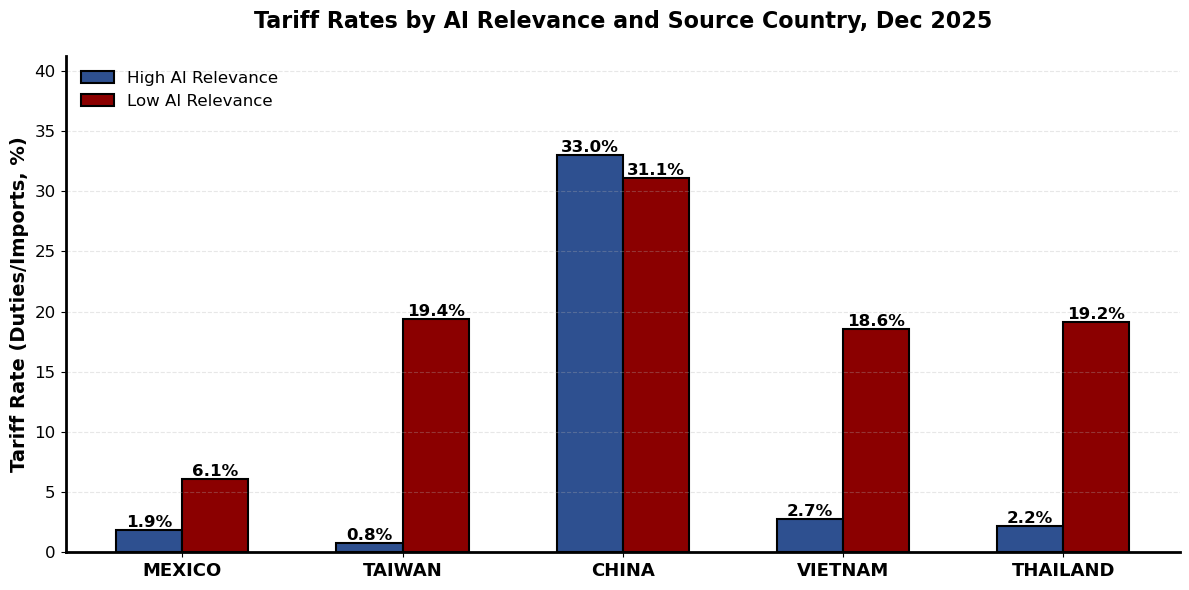


Country tariff rates by AI relevance (Dec 2025):
  MEXICO: High=1.88% | Low=6.06%
  TAIWAN: High=0.80% | Low=19.43%
  CHINA: High=33.01% | Low=31.07%
  VIETNAM: High=2.75% | Low=18.58%
  THAILAND: High=2.21% | Low=19.18%


In [13]:
# Country-specific tariff rates: High vs Low AI relevance (Dec 2025)

country_tariffs_hl = {}

for cty in top5:
    cty_data = dfcountry[
        (dfcountry["CTY_NAME"] == cty) &
        (dfcountry["time"].dt.year == 2025) &
        (dfcountry["time"].dt.month == 12)
    ]
    tariffs = []
    for rel in ["High", "Low"]:
        rel_data = cty_data[cty_data["relevance"] == rel]
        imp = rel_data["imports"].sum()
        tariffs.append((rel_data["duty"].sum() / imp) * 100 if imp > 0 else 0.0)
    country_tariffs_hl[cty] = tariffs

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(top5))
width = 0.30

bars_high = ax.bar(
    x - width/2,
    [country_tariffs_hl[c][0] for c in top5],
    width,
    label="High AI Relevance",
    color="#2E5090",
    edgecolor="black",
    linewidth=1.5
)

bars_low = ax.bar(
    x + width/2,
    [country_tariffs_hl[c][1] for c in top5],
    width,
    label="Low AI Relevance",
    color="#8B0000",
    edgecolor="black",
    linewidth=1.5
)

# Value labels on bars
for bars in [bars_high, bars_low]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

# Formatting
ax.set_ylabel("Tariff Rate (Duties/Imports, %)", fontsize=14, fontweight="bold")
ax.set_title("Tariff Rates by AI Relevance and Source Country, Dec 2025", fontsize=16, fontweight="bold", pad=20)
ax.set_xticks(x)
ax.set_xticklabels(top5)
max_val = max(max(t) for t in country_tariffs_hl.values())
ax.set_ylim(0, max_val * 1.25)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)
ax.legend(fontsize=12, frameon=False, loc="upper left")

plt.savefig(figfile + "ai-tariffs-by-country-relevance.png", bbox_inches="tight")
plt.savefig(figfile + "ai-tariffs-by-country-relevance.pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

print()
print("Country tariff rates by AI relevance (Dec 2025):")
for cty in top5:
    h, l = country_tariffs_hl[cty]
    print(f"  {cty}: High={h:.2f}% | Low={l:.2f}%")


## Tariff Exemption Lists: Why Are AI Tariffs Lower?

Several executive actions in 2025â€“2026 created product-level tariff exemptions. Three exemption lists are loaded from `../data-input/tariff-exemption-lists/`:

1. **Consumer Electronics (EO 14257, Apr 11 2025)** â€” Amendment to IEEPA EO 14257 exempting consumer electronics (phones, laptops, etc.) from reciprocal tariffs. 10-digit HTSUS codes.
2. **Annex II (EO 14257, Apr 11 2025)** â€” Broader product-level exemptions from reciprocal tariffs under EO 14257 Annex II. 10-digit HTSUS codes.
3. **Section 122 Surcharge (Feb 24 2026)** â€” ~1,098 HS codes exempt from the Section 122 surcharge, covering energy, critical minerals, pharma, agriculture, electronics, fertilizers, and semiconductors. Mostly 8-digit codes.

For each list, we check how many AI High-relevance HS10 codes appear and what share of 2025 AI trade they cover.

In [14]:
# Load tariff exemption lists
exempt_electronics = pd.read_csv('../data-input/tariff-exemption-lists/consumer_electronics_EO14257_apr11.csv')
exempt_annex       = pd.read_csv('../data-input/tariff-exemption-lists/annex-II-exemptions.csv')
exempt_s122        = pd.read_csv('../data-input/tariff-exemption-lists/section122-product-exemptions.csv')

# Standardize column names and types
exempt_electronics_codes = set(exempt_electronics['HTSUS'].astype(str).str.strip())
exempt_annex_codes       = set(exempt_annex['HTSUS'].astype(str).str.strip())

# Section 122 has mixed digit lengths; extract and pad to 10 digits for 10-digit codes,
# keep 8-digit codes separate for HS8-level matching
exempt_s122['hts_code'] = exempt_s122['hts_code'].astype(str).str.strip()
exempt_s122_10 = set(exempt_s122[exempt_s122['digits'] == 10]['hts_code'])
exempt_s122_8  = set(exempt_s122[exempt_s122['digits'] == 8]['hts_code'])

print(f"Consumer Electronics (EO 14257, Apr 11):  {len(exempt_electronics_codes):,} codes (10-digit)")
print(f"Annex II (EO 14257, Apr 11):              {len(exempt_annex_codes):,} codes (10-digit)")
print(f"Section 122 Surcharge (Feb 24 2026):      {len(exempt_s122_10):,} codes (10-digit) + {len(exempt_s122_8):,} codes (8-digit)")

Consumer Electronics (EO 14257, Apr 11):  109 codes (10-digit)
Annex II (EO 14257, Apr 11):              720 codes (10-digit)
Section 122 Surcharge (Feb 24 2026):      1 codes (10-digit) + 1,097 codes (8-digit)


In [15]:
# Get AI High-relevance HS10 codes
ai_high = matlist[matlist['relevance'] == 'High'].copy()
ai_high['HS10_str'] = ai_high['HS10'].astype(str)
ai_high['HS8'] = ai_high['HS10_str'].str[:8]

ai_high_codes = set(ai_high['HS10_str'])
ai_high_hs8   = set(ai_high['HS8'])

print(f"AI High-relevance codes: {len(ai_high_codes):,}")
print(f"AI High-relevance unique HS8 prefixes: {len(ai_high_hs8):,}")

AI High-relevance codes: 655
AI High-relevance unique HS8 prefixes: 389


In [16]:
# Match AI High codes against each exemption list

# Consumer Electronics (EO 14257, Apr 11): direct 10-digit match
ai_on_electronics = ai_high_codes & exempt_electronics_codes

# Annex II (EO 14257, Apr 11): direct 10-digit match
ai_on_annex = ai_high_codes & exempt_annex_codes

# Section 122 Surcharge (Feb 24 2026): match at 10-digit where available, then HS8 for 8-digit codes
ai_on_s122_10 = ai_high_codes & exempt_s122_10
ai_on_s122_8 = {code for code in ai_high_codes if code[:8] in exempt_s122_8}
ai_on_s122 = ai_on_s122_10 | ai_on_s122_8

# Union across all lists
ai_on_any = ai_on_electronics | ai_on_annex | ai_on_s122

print(f"AI High codes on exemption lists:")
print(f"  Consumer Electronics (EO 14257, Apr 11):  {len(ai_on_electronics):>4,} / {len(ai_high_codes):,}")
print(f"  Annex II (EO 14257, Apr 11):              {len(ai_on_annex):>4,} / {len(ai_high_codes):,}")
print(f"  Section 122 Surcharge (Feb 2026):         {len(ai_on_s122):>4,} / {len(ai_high_codes):,}")
print(f"    (10-digit matches: {len(ai_on_s122_10):,}, 8-digit matches: {len(ai_on_s122_8 - ai_on_s122_10):,})")
print(f"  Any exemption list:                       {len(ai_on_any):>4,} / {len(ai_high_codes):,}")

AI High codes on exemption lists:
  Consumer Electronics (EO 14257, Apr 11):    82 / 655
  Annex II (EO 14257, Apr 11):                28 / 655
  Section 122 Surcharge (Feb 2026):          127 / 655
    (10-digit matches: 0, 8-digit matches: 127)
  Any exemption list:                        147 / 655


In [17]:
# Trade-weighted analysis: what share of 2025 AI High import value is covered?
df_2025_high = df_reset[(df_reset['time'].dt.year == 2025) & (df_reset['relevance'] == 'High')].copy()
df_2025_high['HS10_str'] = df_2025_high['HS10'].astype(str)

total_ai_imports_2025 = df_2025_high['imports'].sum()

# Flag each row by exemption list membership
df_2025_high['on_electronics'] = df_2025_high['HS10_str'].isin(ai_on_electronics)
df_2025_high['on_annex']       = df_2025_high['HS10_str'].isin(ai_on_annex)
df_2025_high['on_s122']        = df_2025_high['HS10_str'].isin(ai_on_s122)
df_2025_high['on_any']         = df_2025_high['HS10_str'].isin(ai_on_any)

imports_electronics = df_2025_high.loc[df_2025_high['on_electronics'], 'imports'].sum()
imports_annex       = df_2025_high.loc[df_2025_high['on_annex'],       'imports'].sum()
imports_s122        = df_2025_high.loc[df_2025_high['on_s122'],        'imports'].sum()
imports_any         = df_2025_high.loc[df_2025_high['on_any'],         'imports'].sum()

print(f"2025 AI High total imports: ${total_ai_imports_2025/1e9:.1f}B")
print(f"\nTrade value on exemption lists:")
print(f"  Consumer Electronics (EO 14257, Apr 11):  ${imports_electronics/1e9:>6.1f}B  ({imports_electronics/total_ai_imports_2025*100:>5.1f}%)")
print(f"  Annex II (EO 14257, Apr 11):              ${imports_annex/1e9:>6.1f}B  ({imports_annex/total_ai_imports_2025*100:>5.1f}%)")
print(f"  Section 122 Surcharge (Feb 2026):         ${imports_s122/1e9:>6.1f}B  ({imports_s122/total_ai_imports_2025*100:>5.1f}%)")
print(f"  Any exemption list:                       ${imports_any/1e9:>6.1f}B  ({imports_any/total_ai_imports_2025*100:>5.1f}%)")

2025 AI High total imports: $654.0B

Trade value on exemption lists:
  Consumer Electronics (EO 14257, Apr 11):  $ 424.5B  ( 64.9%)
  Annex II (EO 14257, Apr 11):              $  19.4B  (  3.0%)
  Section 122 Surcharge (Feb 2026):         $ 445.9B  ( 68.2%)
  Any exemption list:                       $ 448.6B  ( 68.6%)


In [18]:
# Breakdown by AI category: what share of each category is on any exemption list?
cat_summary = []
for cat in top_4_cats + ['Building_Structure', 'Fire_Safety_Security', 'Specialty_Materials']:
    cat_data = df_2025_high[df_2025_high['primary_category'] == cat]
    cat_total = cat_data['imports'].sum()
    cat_exempt = cat_data.loc[cat_data['on_any'], 'imports'].sum()
    
    # Count codes
    cat_codes = set(cat_data['HS10_str'])
    cat_exempt_codes = cat_codes & ai_on_any
    
    cat_summary.append({
        'Category': cat.replace('_', ' '),
        'HS10 Codes': len(cat_codes),
        'Exempt Codes': len(cat_exempt_codes),
        'Code Share (%)': len(cat_exempt_codes) / len(cat_codes) * 100 if cat_codes else 0,
        '2025 Imports ($B)': cat_total / 1e9,
        'Exempt Imports ($B)': cat_exempt / 1e9,
        'Import Share (%)': cat_exempt / cat_total * 100 if cat_total > 0 else 0,
    })

cat_df = pd.DataFrame(cat_summary)
print(cat_df.to_string(index=False, float_format='%.1f'))

            Category  HS10 Codes  Exempt Codes  Code Share (%)  2025 Imports ($B)  Exempt Imports ($B)  Import Share (%)
    Compute Hardware         160            84            52.5              353.8                344.3              97.3
    Electrical Power         250            26            10.4              141.8                 19.1              13.5
  Networking Telecom          24             4            16.7               99.5                 84.8              85.1
        Cooling HVAC         136             4             2.9               47.5                  0.2               0.4
  Building Structure          44             0             0.0               10.1                  0.0               0.0
Fire Safety Security           8             0             0.0                0.7                  0.0               0.0
 Specialty Materials          19            16            84.2                0.5                  0.3              60.8


In [19]:
# Write exemption coverage macros to LaTeX file
with open(texfile, 'a') as f:
    # Overall exemption coverage
    any_pct = imports_any / total_ai_imports_2025 * 100
    ce_dollars = imports_electronics / 1e9
    f.write(f'\\def\\exemptionAnyPct{{{any_pct:.0f}}} % Share of AI High imports on any exemption list (%)\n')
    f.write(f'\\def\\exemptionCEDollars{{{ce_dollars:.0f}}} % Consumer Electronics exemption coverage ($B)\n')

    # Per-category exemption coverage
    for _, row in cat_df.iterrows():
        cat_clean = row['Category'].replace(' ', '')
        f.write(f'\\def\\exemption{cat_clean}Pct{{{row["Import Share (%)"]:.1f}}} % {row["Category"]} exemption coverage (%)\n')

print(f"Appended exemption macros to {texfile}:")
print(f"  Any exemption list: {any_pct:.0f}%")
print(f"  Consumer Electronics: ${ce_dollars:.0f}B")
for _, row in cat_df.iterrows():
    print(f"  {row['Category']}: {row['Import Share (%)']:.1f}%")


Appended exemption macros to ../paper/tables/ai-trade-results.tex:
  Any exemption list: 69%
  Consumer Electronics: $424B
  Compute Hardware: 97.3%
  Electrical Power: 13.5%
  Networking Telecom: 85.1%
  Cooling HVAC: 0.4%
  Building Structure: 0.0%
  Fire Safety Security: 0.0%
  Specialty Materials: 60.8%


In [20]:
# Compare effective tariff rates: exempt vs non-exempt AI products
df_2025_high['exempt_status'] = df_2025_high['on_any'].map({True: 'Exempt', False: 'Not Exempt'})

tariff_by_exempt = df_2025_high.groupby('exempt_status').agg(
    total_imports=('imports', 'sum'),
    total_duty=('duty', 'sum'),
    n_codes=('HS10_str', 'nunique')
).assign(tariff_rate=lambda x: x['total_duty'] / x['total_imports'] * 100)

print("2025 Effective Tariff Rates: Exempt vs Non-Exempt AI Products")
print("=" * 65)
for status, row in tariff_by_exempt.iterrows():
    print(f"  {status:12s}: tariff={row['tariff_rate']:.2f}%  "
          f"imports=${row['total_imports']/1e9:.1f}B  "
          f"codes={int(row['n_codes']):,}")

2025 Effective Tariff Rates: Exempt vs Non-Exempt AI Products
  Exempt      : tariff=1.03%  imports=$448.6B  codes=134
  Not Exempt  : tariff=12.71%  imports=$205.4B  codes=507


In [21]:
# For comparison: how many Low-relevance codes are on exemption lists?
low_codes = set(matlist[matlist['relevance'] == 'Low']['HS10'].astype(str))

low_on_electronics = low_codes & exempt_electronics_codes
low_on_annex = low_codes & exempt_annex_codes
low_on_s122_10 = low_codes & exempt_s122_10
low_on_s122_8 = {c for c in low_codes if c[:8] in exempt_s122_8}
low_on_s122 = low_on_s122_10 | low_on_s122_8
low_on_any = low_on_electronics | low_on_annex | low_on_s122

df_2025_low = df_reset[(df_reset['time'].dt.year == 2025) & (df_reset['relevance'] == 'Low')].copy()
df_2025_low['HS10_str'] = df_2025_low['HS10'].astype(str)
total_low_2025 = df_2025_low['imports'].sum()
exempt_low_2025 = df_2025_low[df_2025_low['HS10_str'].isin(low_on_any)]['imports'].sum()

print(f"Low-relevance codes on ANY exemption list: {len(low_on_any):,} / {len(low_codes):,} ({len(low_on_any)/len(low_codes)*100:.1f}%)")
print(f"Low-relevance 2025 exempt imports: ${exempt_low_2025/1e9:.1f}B / ${total_low_2025/1e9:.1f}B ({exempt_low_2025/total_low_2025*100:.1f}%)")
print()
print(f"Summary comparison (AI High vs Low):")
print(f"  AI High: {len(ai_on_any):>4,} / {len(ai_high_codes):>6,} codes exempt ({len(ai_on_any)/len(ai_high_codes)*100:>5.1f}%), covering {imports_any/total_ai_imports_2025*100:.1f}% of 2025 trade")
print(f"  Low:     {len(low_on_any):>4,} / {len(low_codes):>6,} codes exempt ({len(low_on_any)/len(low_codes)*100:>5.1f}%), covering {exempt_low_2025/total_low_2025*100:.1f}% of 2025 trade")

Low-relevance codes on ANY exemption list: 1,122 / 16,187 (6.9%)
Low-relevance 2025 exempt imports: $448.9B / $1880.9B (23.9%)

Summary comparison (AI High vs Low):
  AI High:  147 /    655 codes exempt ( 22.4%), covering 68.6% of 2025 trade
  Low:     1,122 / 16,187 codes exempt (  6.9%), covering 23.9% of 2025 trade


In [22]:
# Write exemption coverage tables to LaTeX

# Table 1: Exemption list coverage of AI High imports
table1_file = "../paper/tables/exemption_coverage.tex"
with open(table1_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\caption{Tariff Exemption Coverage of AI High-Relevance Imports (2025)}\n")
    f.write("\\label{tab:exemption_coverage}\n")
    f.write("\\setlength{\\tabcolsep}{1.95mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.60}\n")
    f.write("{\\small\n")
    f.write("\\begin{tabular}{lccc}\n")
    f.write("\\toprule\n")
    f.write("Exemption List & \\# HS10 Codes & AI High Trade (\\$B) & Share of AI High (\\%) \\\\\n")
    f.write("\\midrule\n")
    f.write(f"Consumer Electronics (EO 14257, Apr 11) & {len(exempt_electronics_codes):,} & {imports_electronics/1e9:.1f} & {imports_electronics/total_ai_imports_2025*100:.1f} \\\\\n")
    f.write(f"Annex II (EO 14257, Apr 11) & {len(exempt_annex_codes):,} & {imports_annex/1e9:.1f} & {imports_annex/total_ai_imports_2025*100:.1f} \\\\\n")
    f.write(f"Section 122 Surcharge (Feb 2026) & {len(exempt_s122_10) + len(exempt_s122_8):,} & {imports_s122/1e9:.1f} & {imports_s122/total_ai_imports_2025*100:.1f} \\\\\n")
    f.write("\\midrule\n")
    f.write(f"Any Exemption List & --- & {imports_any/1e9:.1f} & {imports_any/total_ai_imports_2025*100:.1f} \\\\\n")
    f.write("\\bottomrule\n")
    f.write("\\end{tabular}}\n")
    f.write("\\end{table}\n")

print(f"Generated: {table1_file}")
with open(table1_file, 'r', encoding='utf-8') as f:
    print(f.read())

Generated: ../paper/tables/exemption_coverage.tex
\begin{table}[htbp]
\centering
\caption{Tariff Exemption Coverage of AI High-Relevance Imports (2025)}
\label{tab:exemption_coverage}
\setlength{\tabcolsep}{1.95mm}
\renewcommand{\arraystretch}{1.60}
{\small
\begin{tabular}{lccc}
\toprule
Exemption List & \# HS10 Codes & AI High Trade (\$B) & Share of AI High (\%) \\
\midrule
Consumer Electronics (EO 14257, Apr 11) & 109 & 424.5 & 64.9 \\
Annex II (EO 14257, Apr 11) & 720 & 19.4 & 3.0 \\
Section 122 Surcharge (Feb 2026) & 1,098 & 445.9 & 68.2 \\
\midrule
Any Exemption List & --- & 448.6 & 68.6 \\
\bottomrule
\end{tabular}}
\end{table}



In [23]:
# Table 2: Exemption coverage by AI category
table2_file = "../paper/tables/exemption_by_category.tex"
with open(table2_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\caption{Tariff Exemption Coverage by AI Product Category (2025)}\n")
    f.write("\\label{tab:exemption_by_category}\n")
    f.write("\\setlength{\\tabcolsep}{3mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.60}\n")
    f.write("\\begin{tabular}{lrrrrrr}\n")
    f.write("\\toprule\n")
    f.write("Category & \\# HS10 & Exempt & Code Share & 2025 Imports & Exempt Imports & Import Share \\\\\n")
    f.write(" & Codes & Codes & (\\%) & (\\$B) & (\\$B) & (\\%) \\\\\n")
    f.write("\\midrule\n")
    for _, row in cat_df.iterrows():
        f.write(f"{row['Category']} & {int(row['HS10 Codes'])} & {int(row['Exempt Codes'])} & "
                f"{row['Code Share (%)']:.1f} & {row['2025 Imports ($B)']:.1f} & "
                f"{row['Exempt Imports ($B)']:.1f} & {row['Import Share (%)']:.1f} \\\\\n")
    f.write("\\bottomrule\n")
    f.write("\\end{tabular}\n")
    f.write("\\end{table}\n")

print(f"Generated: {table2_file}")
with open(table2_file, 'r', encoding='utf-8') as f:
    print(f.read())

Generated: ../paper/tables/exemption_by_category.tex
\begin{table}[htbp]
\centering
\caption{Tariff Exemption Coverage by AI Product Category (2025)}
\label{tab:exemption_by_category}
\setlength{\tabcolsep}{3mm}
\renewcommand{\arraystretch}{1.60}
\begin{tabular}{lrrrrrr}
\toprule
Category & \# HS10 & Exempt & Code Share & 2025 Imports & Exempt Imports & Import Share \\
 & Codes & Codes & (\%) & (\$B) & (\$B) & (\%) \\
\midrule
Compute Hardware & 160 & 84 & 52.5 & 353.8 & 344.3 & 97.3 \\
Electrical Power & 250 & 26 & 10.4 & 141.8 & 19.1 & 13.5 \\
Networking Telecom & 24 & 4 & 16.7 & 99.5 & 84.8 & 85.1 \\
Cooling HVAC & 136 & 4 & 2.9 & 47.5 & 0.2 & 0.4 \\
Building Structure & 44 & 0 & 0.0 & 10.1 & 0.0 & 0.0 \\
Fire Safety Security & 8 & 0 & 0.0 & 0.7 & 0.0 & 0.0 \\
Specialty Materials & 19 & 16 & 84.2 & 0.5 & 0.3 & 60.8 \\
\bottomrule
\end{tabular}
\end{table}

